###   Project 2: Statistical Plots & Distribution Analysis

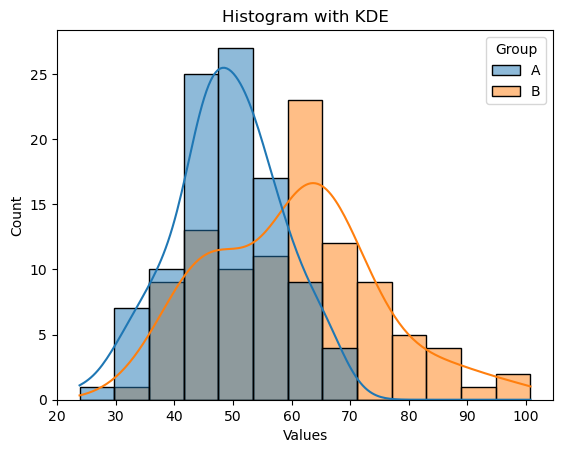

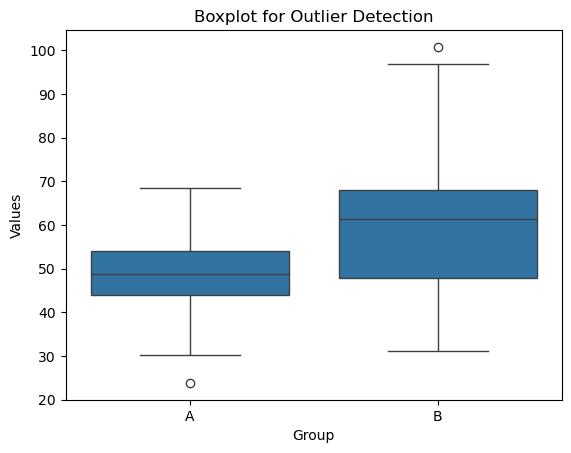


Statistical Summary:
       count       mean        std        min        25%        50%  \
Group                                                                 
A      100.0  48.961535   9.081684  23.802549  43.990943  48.730437   
B      100.0  60.334569  14.305034  31.218432  47.915092  61.261608   

             75%         max  
Group                         
A      54.059521   68.522782  
B      68.072557  100.802537  

Skewness:
Group
A   -0.177948
B    0.386984
Name: Values, dtype: float64

Outliers in Group A:
   Group     Values
74     A  23.802549

Outliers in Group B:
    Group      Values
179     B  100.802537


In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

np.random.seed(42)

data = pd.DataFrame({
    "Group": ["A"]*100 + ["B"]*100,
    "Values": np.concatenate([
        np.random.normal(50, 10, 100),
        np.random.normal(60, 15, 100)
    ])
})

plt.figure()
sns.histplot(data=data, x="Values", hue="Group", kde=True)
plt.title("Histogram with KDE")
plt.savefig("hist_kde.png")
plt.show()

plt.figure()
sns.boxplot(data=data, x="Group", y="Values")
plt.title("Boxplot for Outlier Detection")
plt.savefig("boxplot.png")
plt.show()

print("\nStatistical Summary:")
print(data.groupby("Group")["Values"].describe())

print("\nSkewness:")
print(data.groupby("Group")["Values"].skew())

def detect_outliers(df):
    Q1 = df["Values"].quantile(0.25)
    Q3 = df["Values"].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df["Values"] < lower) | (df["Values"] > upper)]
    return outliers

print("\nOutliers in Group A:")
print(detect_outliers(data[data["Group"]=="A"]))

print("\nOutliers in Group B:")
print(detect_outliers(data[data["Group"]=="B"]))